<a href="https://colab.research.google.com/github/alperdinceler/Machine-learning/blob/main/Eigenfaces_olivetti_faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import cv2
from scipy import datasets as scd
from sklearn.datasets import load_digits, fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')

faces = fetch_olivetti_faces()
X_flat = faces.data
y_digits = faces.target
X_digits = faces.images

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

plt.rcParams['figure.dpi'] = 100
print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")
print(f"Feature size: {X_flat.shape[1]}")

Train samples: 320 | Test samples: 80
Feature size: 4096


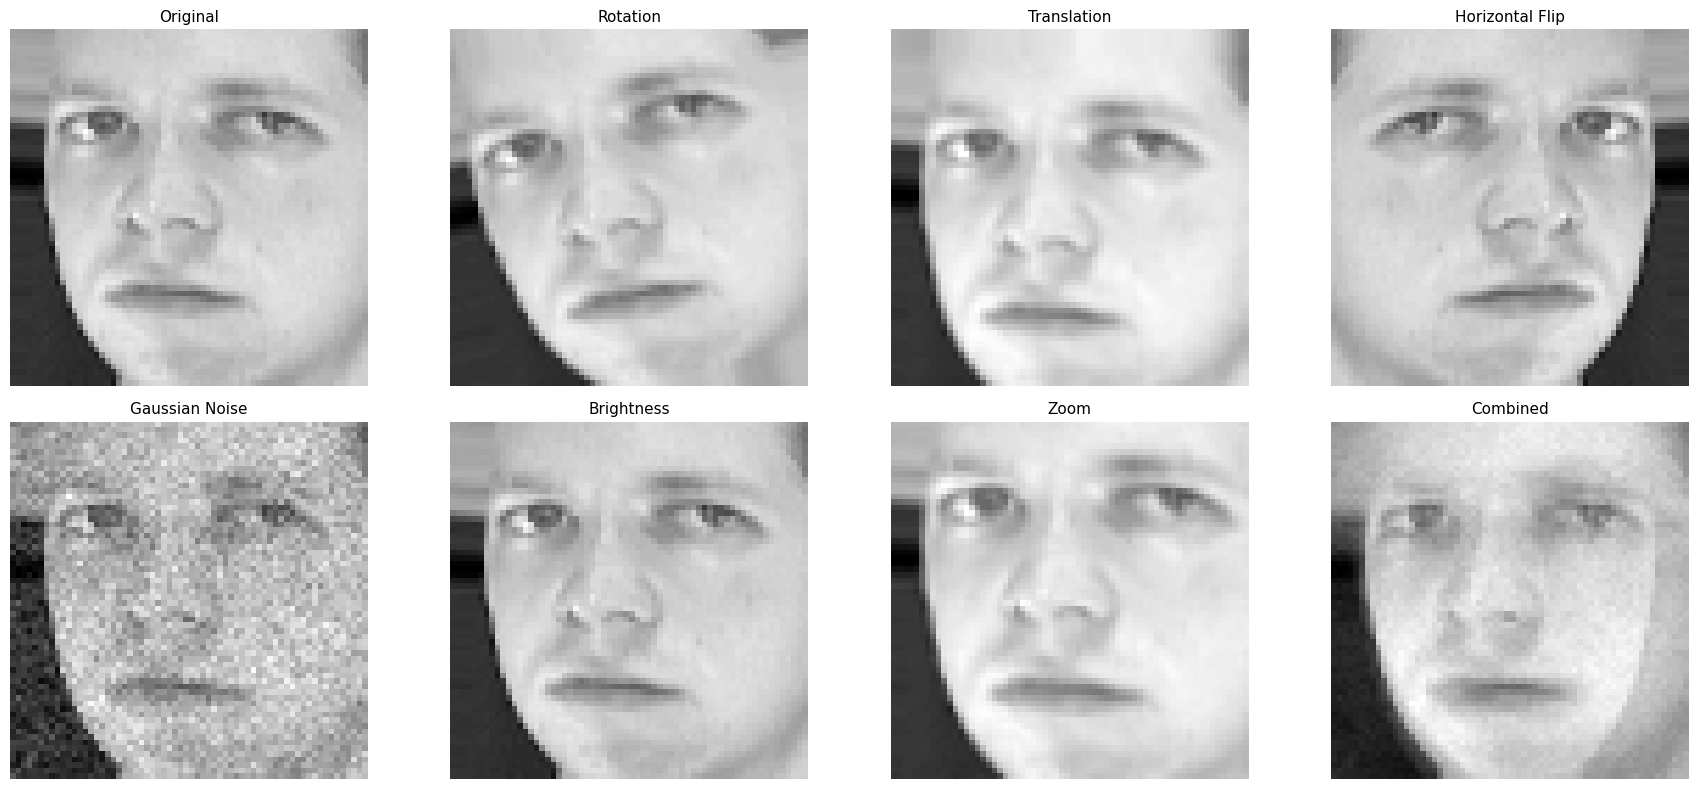

In [31]:
def augment_image(img_2d, seed=None):
    rng = np.random.default_rng(seed)
    img_uint8 = (img_2d * 255.0).astype(np.uint8)
    results = {'original': img_2d.copy()}

    angle = rng.uniform(-25, 25)
    h, w  = img_uint8.shape
    M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    results['rotation'] = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REPLICATE).astype(float) / 255.0

    tx, ty = rng.uniform(-5.0, 5.0), rng.uniform(-5.0, 5.0)
    M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    results['translation'] = cv2.warpAffine(img_uint8, M_trans, (w, h), borderMode=cv2.BORDER_REPLICATE).astype(float) / 255.0

    results['flip'] = np.fliplr(img_uint8).astype(float) / 255.0

    sigma  = rng.uniform(5, 20)
    noise  = rng.normal(0, sigma, img_uint8.shape).astype(np.int16)
    results['noise'] = np.clip(img_uint8.astype(np.int16) + noise, 0, 255).astype(np.uint8).astype(float) / 255.0

    factor = rng.uniform(0.6, 1.6)
    results['brightness'] = np.clip(img_uint8.astype(float) * factor, 0, 255).astype(np.uint8).astype(float) / 255.0

    zoom   = rng.uniform(0.7, 0.95)
    crop_h, crop_w = int(h * zoom), int(w * zoom)
    y0, x0 = rng.integers(0, h - crop_h + 1), rng.integers(0, w - crop_w + 1)
    cropped = img_uint8[y0:y0+crop_h, x0:x0+crop_w]
    results['zoom'] = cv2.resize(cropped, (w, h)).astype(float) / 255.0

    return results

sample_img = X_digits[5]
aug_results = augment_image(sample_img, seed=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

titles = ['Original', 'Rotation', 'Translation', 'Horizontal Flip', 'Gaussian Noise', 'Brightness', 'Zoom', 'Combined']

for i, (key, img) in enumerate(aug_results.items()):
    axes[i].imshow(img, cmap='gray', interpolation='nearest')
    axes[i].set_title(titles[i], fontsize=11)
    axes[i].axis('off')

combined = np.mean(list(aug_results.values()), axis=0)
axes[7].imshow(combined, cmap='gray', interpolation='nearest')
axes[7].set_title(titles[7], fontsize=11)
axes[7].axis('off')

plt.tight_layout()
plt.show()

In [32]:

def build_augmented_dataset(X_img, y, n_aug=3, seed=0):
    X_list, y_list = [X_img.flatten().reshape(len(X_img), -1)], [y]
    rng = np.random.default_rng(seed)

    for aug_round in range(n_aug):
        X_new = []
        for i, img in enumerate(X_img):
            s = rng.integers(0, 10000)
            aug = augment_image(img, seed=int(s))
            key = list(aug.keys())[1 + (aug_round % 6)]
            X_new.append(aug[key].flatten())
        X_list.append(np.array(X_new))
        y_list.append(y)

    return np.vstack(X_list), np.concatenate(y_list)

print("Augmentation uygulanıyor...")
X_train_imgs = X_digits[np.isin(np.arange(len(y_digits)),
               np.where(np.isin(y_digits, np.unique(y_train)))[0])]

train_idx, test_idx, _, _ = train_test_split(
    np.arange(len(y_digits)), y_digits, test_size=0.25, random_state=42, stratify=y_digits
)
X_tr_imgs = X_digits[train_idx]
y_tr      = y_digits[train_idx]
X_te_flat = X_digits[test_idx].reshape(len(test_idx), -1)
y_te      = y_digits[test_idx]


X_aug, y_aug = build_augmented_dataset(X_tr_imgs, y_tr, n_aug=3)
print(f"Orijinal eğitim seti  : {len(y_tr)} örnek")
print(f"Augmented eğitim seti : {len(y_aug)} örnek  (4× büyüdü)")


sc = StandardScaler()
X_tr_sc  = sc.fit_transform(X_flat[train_idx])
X_aug_sc = sc.fit_transform(X_aug)
X_te_sc  = sc.transform(X_te_flat)

mlp_orig = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=42)
mlp_aug  = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=42)

mlp_orig.fit(X_tr_sc,  y_tr)
mlp_aug.fit(X_aug_sc, y_aug)

acc_orig = accuracy_score(y_te, mlp_orig.predict(X_te_sc))
acc_aug  = accuracy_score(y_te, mlp_aug.predict(X_te_sc))

print(f"\nTest Doğruluğu — Orijinal veri : {acc_orig*100:.2f}%")
print(f"Test Doğruluğu — Augmented veri: {acc_aug*100:.2f}%")
print(f"Augmentation kazancı            : {(acc_aug-acc_orig)*100:+.2f} puan")


Augmentation uygulanıyor...
Orijinal eğitim seti  : 300 örnek
Augmented eğitim seti : 1200 örnek  (4× büyüdü)

Test Doğruluğu — Orijinal veri : 95.00%
Test Doğruluğu — Augmented veri: 97.00%
Augmentation kazancı            : +2.00 puan


%90 varyans için gerekli bileşen: 66
%95 varyans için gerekli bileşen: 123
%99 varyans için gerekli bileşen: 260
Orijinal boyut: 4096  →  Sıkıştırma oranı (%90): 62.1×


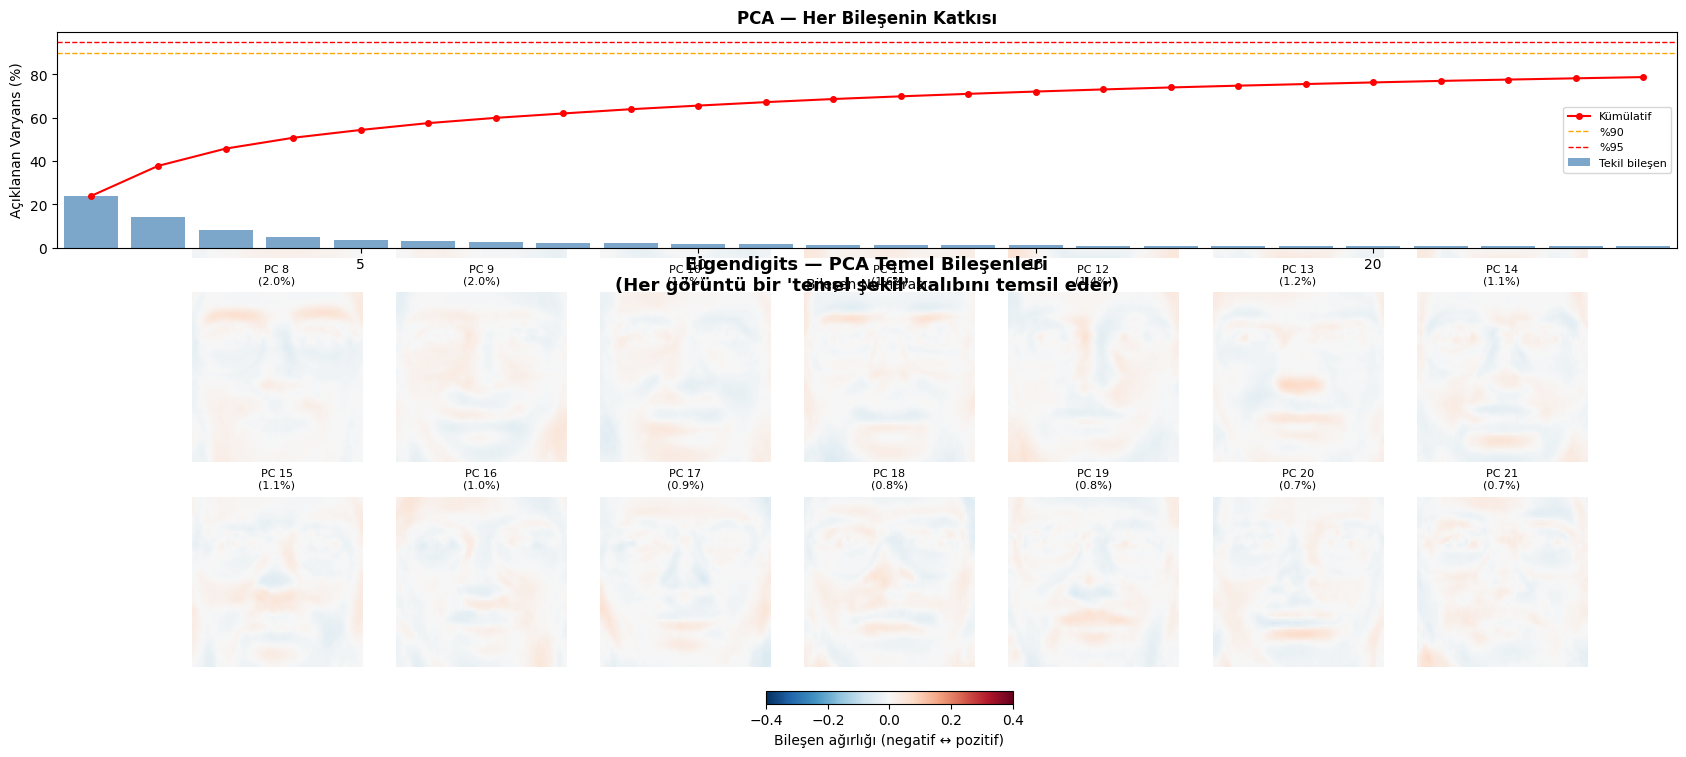

In [33]:
pca_full = PCA()
pca_full.fit(X_flat)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90  = np.searchsorted(cumvar, 0.90) + 1
n95  = np.searchsorted(cumvar, 0.95) + 1
n99  = np.searchsorted(cumvar, 0.99) + 1

print(f"%90 varyans için gerekli bileşen: {n90}")
print(f"%95 varyans için gerekli bileşen: {n95}")
print(f"%99 varyans için gerekli bileşen: {n99}")
print(f"Orijinal boyut: 4096  →  Sıkıştırma oranı (%90): {4096/n90:.1f}×")

fig, axes = plt.subplots(3, 7, figsize=(18, 8))

ax_var = fig.add_axes([0.05, 0.68, 0.90, 0.27])
ax_var.bar(range(1, 25), pca_full.explained_variance_ratio_[:24]*100,
           color='steelblue', alpha=0.7, label='Tekil bileşen')
ax_var.plot(range(1, 25), cumvar[:24]*100,
            'ro-', markersize=4, linewidth=1.5, label='Kümülatif')
ax_var.axhline(y=90, color='orange', linestyle='--', linewidth=1, label='%90')
ax_var.axhline(y=95, color='red',    linestyle='--', linewidth=1, label='%95')
ax_var.set_xlabel("Bileşen Numarası")
ax_var.set_ylabel("Açıklanan Varyans (%)")
ax_var.set_title("PCA — Her Bileşenin Katkısı", fontweight='bold')
ax_var.legend(loc='right', fontsize=8)
ax_var.set_xlim(0.5, 24.5)

for i, ax in enumerate(axes.flatten()):
    if i < 21:
        eigenimg = pca_full.components_[i].reshape(64, 64)
        im = ax.imshow(eigenimg, cmap='RdBu_r',
                       vmin=-0.4, vmax=0.4)
        ax.set_title(f"PC {i+1}\n({pca_full.explained_variance_ratio_[i]*100:.1f}%)",
                     fontsize=8)
        ax.axis('off')

fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.02, pad=0.04,
             label='Bileşen ağırlığı (negatif ↔ pozitif)')

plt.suptitle("Eigendigits — PCA Temel Bileşenleri\n(Her görüntü bir 'temel şekil' kalıbını temsil eder)",
             fontsize=13, fontweight='bold', y=0.67)
plt.show()


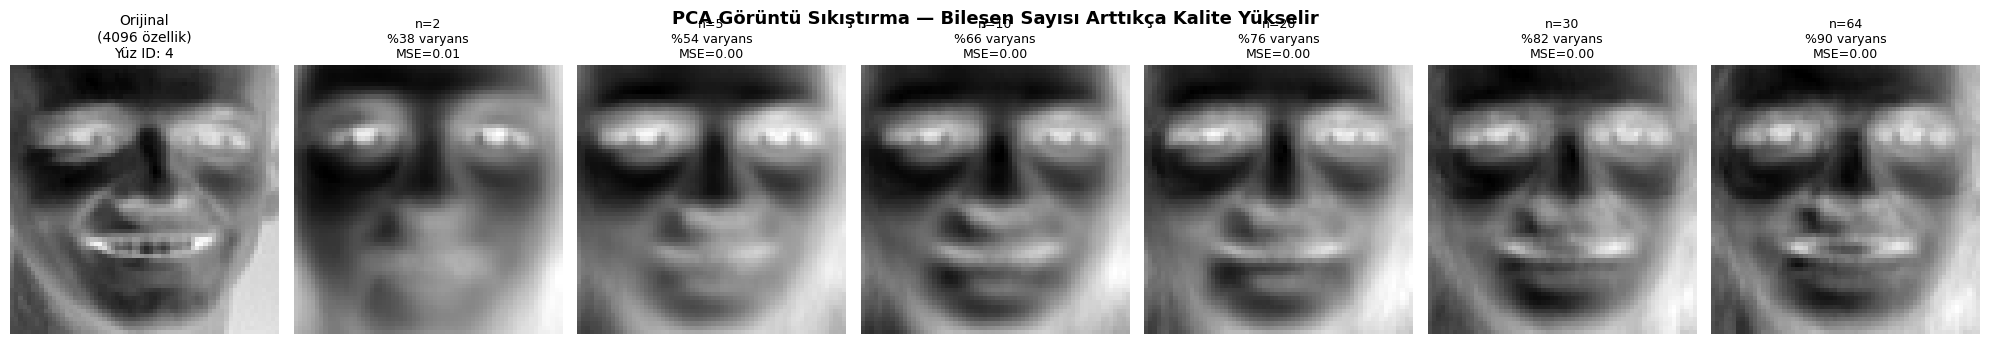

In [34]:
n_components_list = [2, 5, 10, 20, 30, 64]
sample_idx = 42
original   = X_flat[sample_idx]

fig, axes = plt.subplots(1, len(n_components_list)+1, figsize=(20, 3.5))

axes[0].imshow(original.reshape(64,64), cmap='gray_r', interpolation='nearest')
axes[0].set_title(f"Orijinal\n(4096 özellik)\nYüz ID: {y_digits[sample_idx]}", fontsize=10)
axes[0].axis('off')

for j, n in enumerate(n_components_list):
    pca_n = PCA(n_components=n)
    pca_n.fit(X_flat)

    compressed = pca_n.transform(X_flat[sample_idx:sample_idx+1])
    reconstructed = pca_n.inverse_transform(compressed)

    mse = np.mean((original - reconstructed[0])**2)
    var_exp = np.sum(pca_n.explained_variance_ratio_) * 100

    axes[j+1].imshow(reconstructed[0].reshape(64,64), cmap='gray_r', interpolation='nearest')
    axes[j+1].set_title(f"n={n}\n%{var_exp:.0f} varyans\nMSE={mse:.2f}", fontsize=9)
    axes[j+1].axis('off')

plt.suptitle("PCA Görüntü Sıkıştırma — Bileşen Sayısı Arttıkça Kalite Yükselir",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


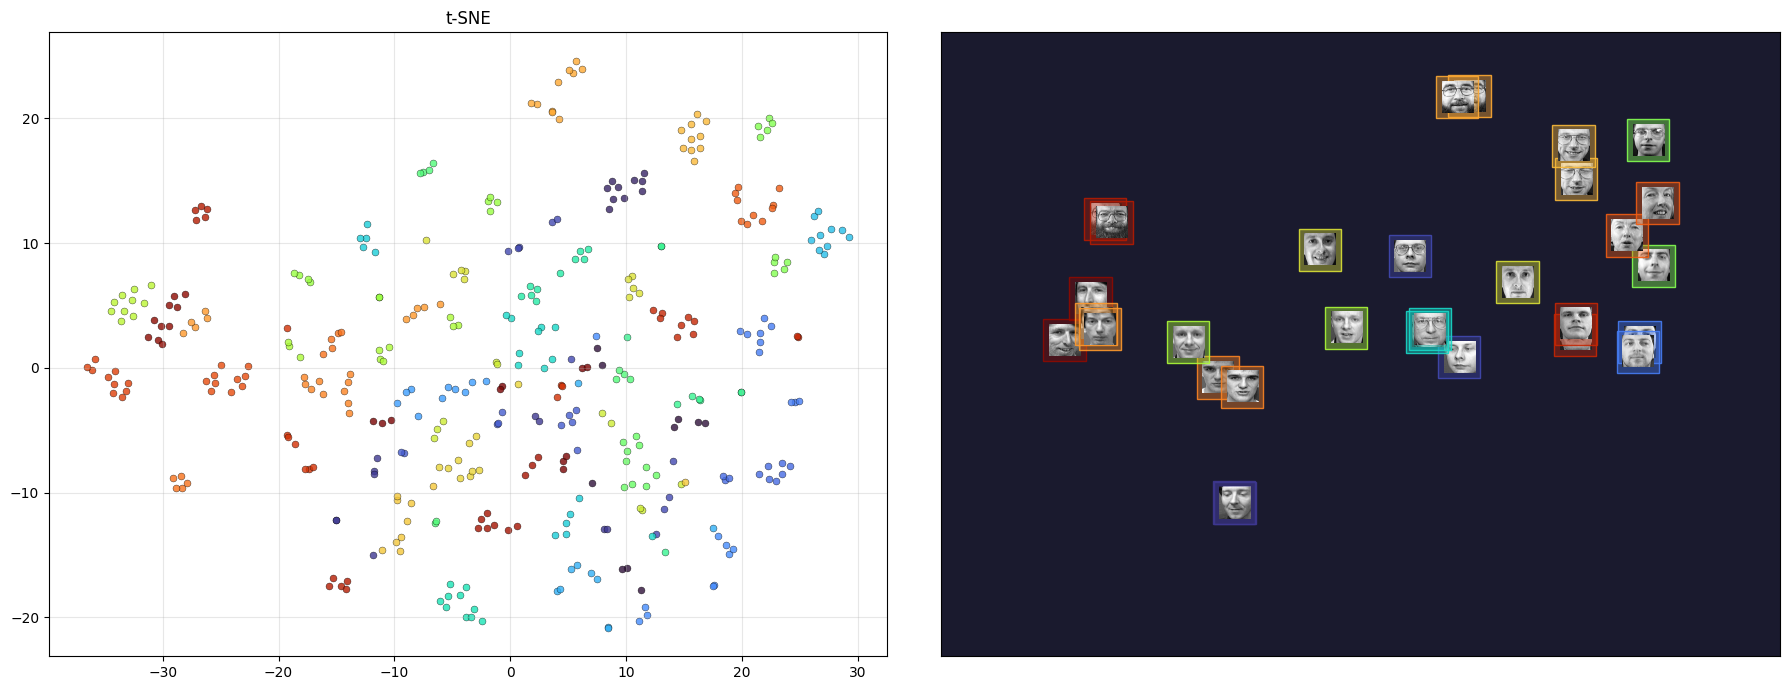

In [35]:
pca30 = PCA(n_components=30, random_state=42)
X_pca30 = pca30.fit_transform(X_flat)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_pca30)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
n_classes = len(np.unique(y_digits))
colors = plt.cm.turbo(np.linspace(0, 1, n_classes))

for face_id in range(n_classes):
    mask = y_digits == face_id
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[colors[face_id]], alpha=0.8, s=25, edgecolors='k', linewidths=0.3)

axes[0].set_title("t-SNE")
axes[0].grid(True, alpha=0.3)

axes[1].set_facecolor('#1a1a2e')
axes[1].set_title("t-SNE Samples", color='white')

from matplotlib.offsetbox import AnnotationBbox, OffsetImage
rng = np.random.default_rng(42)
selected_faces = rng.choice(n_classes, size=15, replace=False)

for face_id in selected_faces:
    mask_idx = np.where(y_digits == face_id)[0]
    sample_indices = rng.choice(mask_idx, size=min(2, len(mask_idx)), replace=False)
    for idx in sample_indices:
        img = X_digits[idx]
        imagebox = OffsetImage(img, zoom=0.35, cmap='gray')
        ab = AnnotationBbox(imagebox, (X_tsne[idx, 0], X_tsne[idx, 1]), frameon=True, bboxprops=dict(facecolor=(*colors[face_id][:3], 0.4), edgecolor=(*colors[face_id][:3], 0.9)))
        axes[1].add_artist(ab)

axes[1].set_xlim(X_tsne[:,0].min()-5, X_tsne[:,0].max()+5)
axes[1].set_ylim(X_tsne[:,1].min()-5, X_tsne[:,1].max()+5)
axes[1].tick_params(colors='white')
plt.tight_layout()
plt.show()

In [36]:
svm_pipeline = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

knn_pipeline = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=3, weights='distance'))
])

svm_pipeline.fit(X_train_sc, y_train)
knn_pipeline.fit(X_train_sc, y_train)

y_pred_svm = svm_pipeline.predict(X_test_sc)
y_pred_knn = knn_pipeline.predict(X_test_sc)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

SVM Accuracy: 0.9500
KNN Accuracy: 0.9250


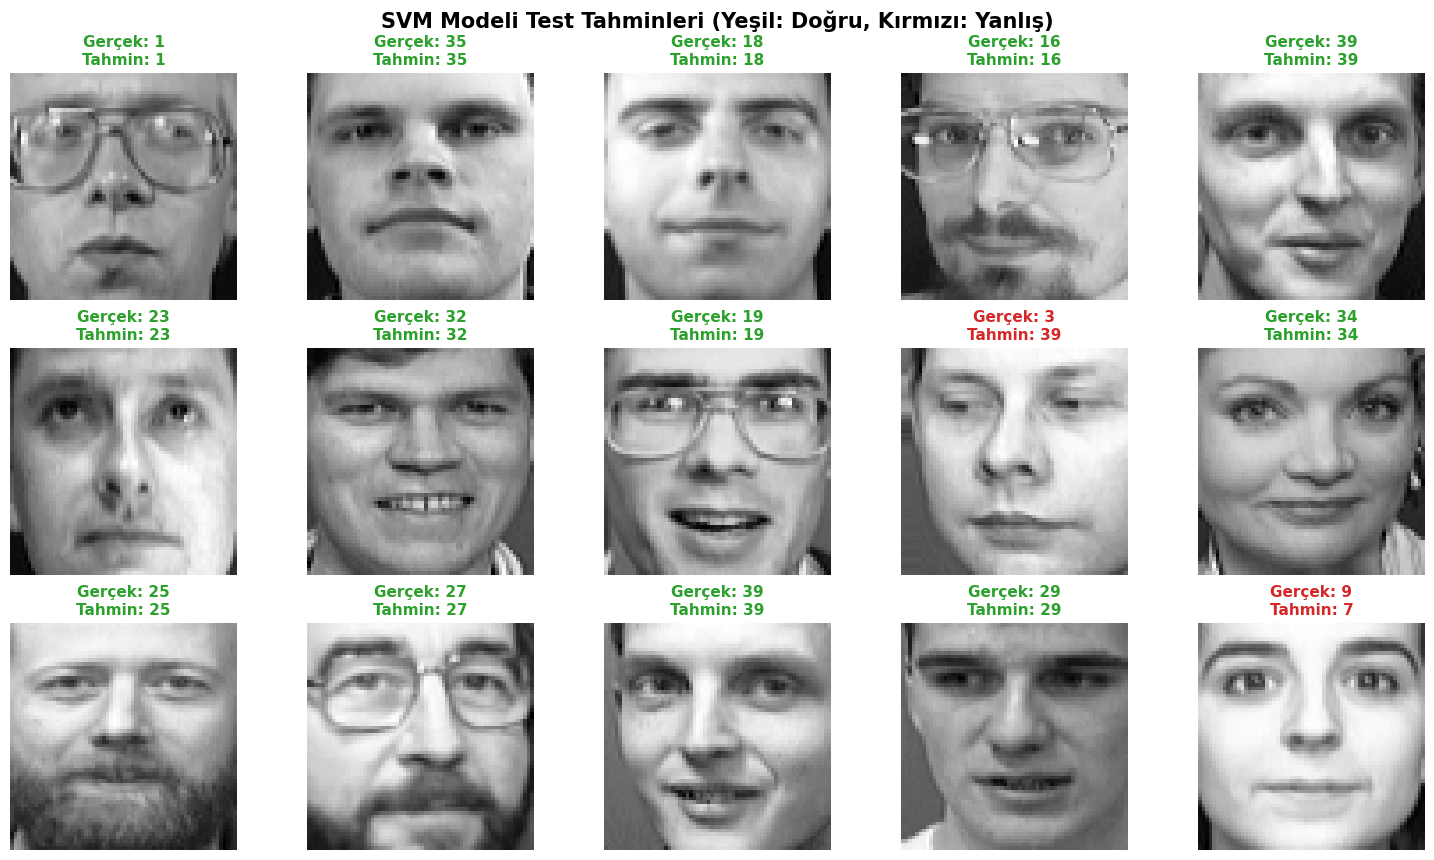

In [37]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, ax in enumerate(axes.flatten()):
    if i < len(X_test):

        img = X_test[i].reshape(64, 64)
        true_label = y_test[i]
        pred_label = y_pred_svm[i]
        color = '#2ca02c' if true_label == pred_label else '#d62728'
        ax.imshow(img, cmap='gray', interpolation='nearest')
        ax.set_title(f"Gerçek: {true_label}\nTahmin: {pred_label}", color=color, fontweight='bold', fontsize=11)

    ax.axis('off')

plt.suptitle("SVM Modeli Test Tahminleri (Yeşil: Doğru, Kırmızı: Yanlış)", fontsize=15, fontweight='bold', y=0.95)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Errors (SVM): 4


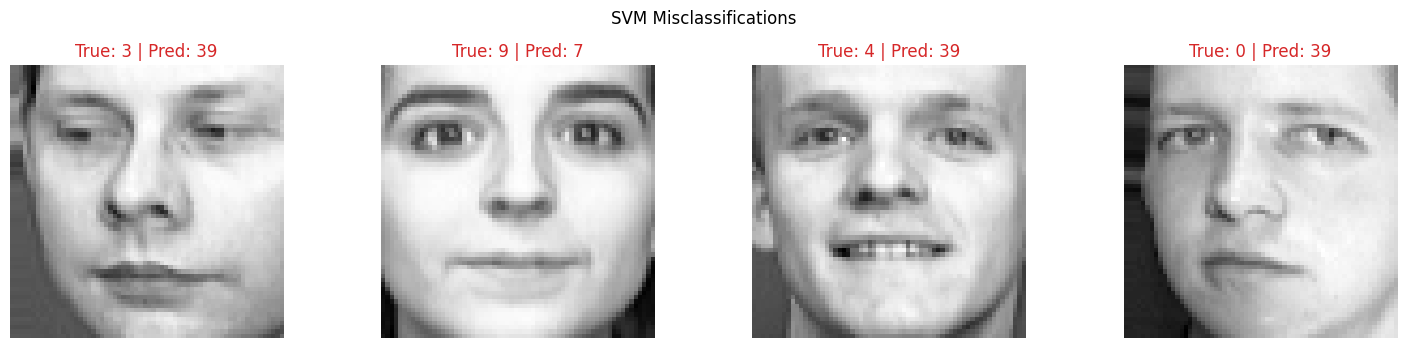

In [38]:
hatali_indeksler = np.where(y_test != y_pred_svm)[0]

print(f"Errors (SVM): {len(hatali_indeksler)}")

if len(hatali_indeksler) > 0:
    cols = min(5, len(hatali_indeksler))
    rows = (len(hatali_indeksler) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    axes_flat = np.array(axes).flatten()

    for i, ax in enumerate(axes_flat):
        if i < len(hatali_indeksler):
            idx = hatali_indeksler[i]
            ax.imshow(X_test[idx].reshape(64, 64), cmap='gray', interpolation='nearest')
            ax.set_title(f"True: {y_test[idx]} | Pred: {y_pred_svm[idx]}", color='#d62728')
        ax.axis('off')

    plt.suptitle("SVM Misclassifications")
    plt.tight_layout()
    plt.show()

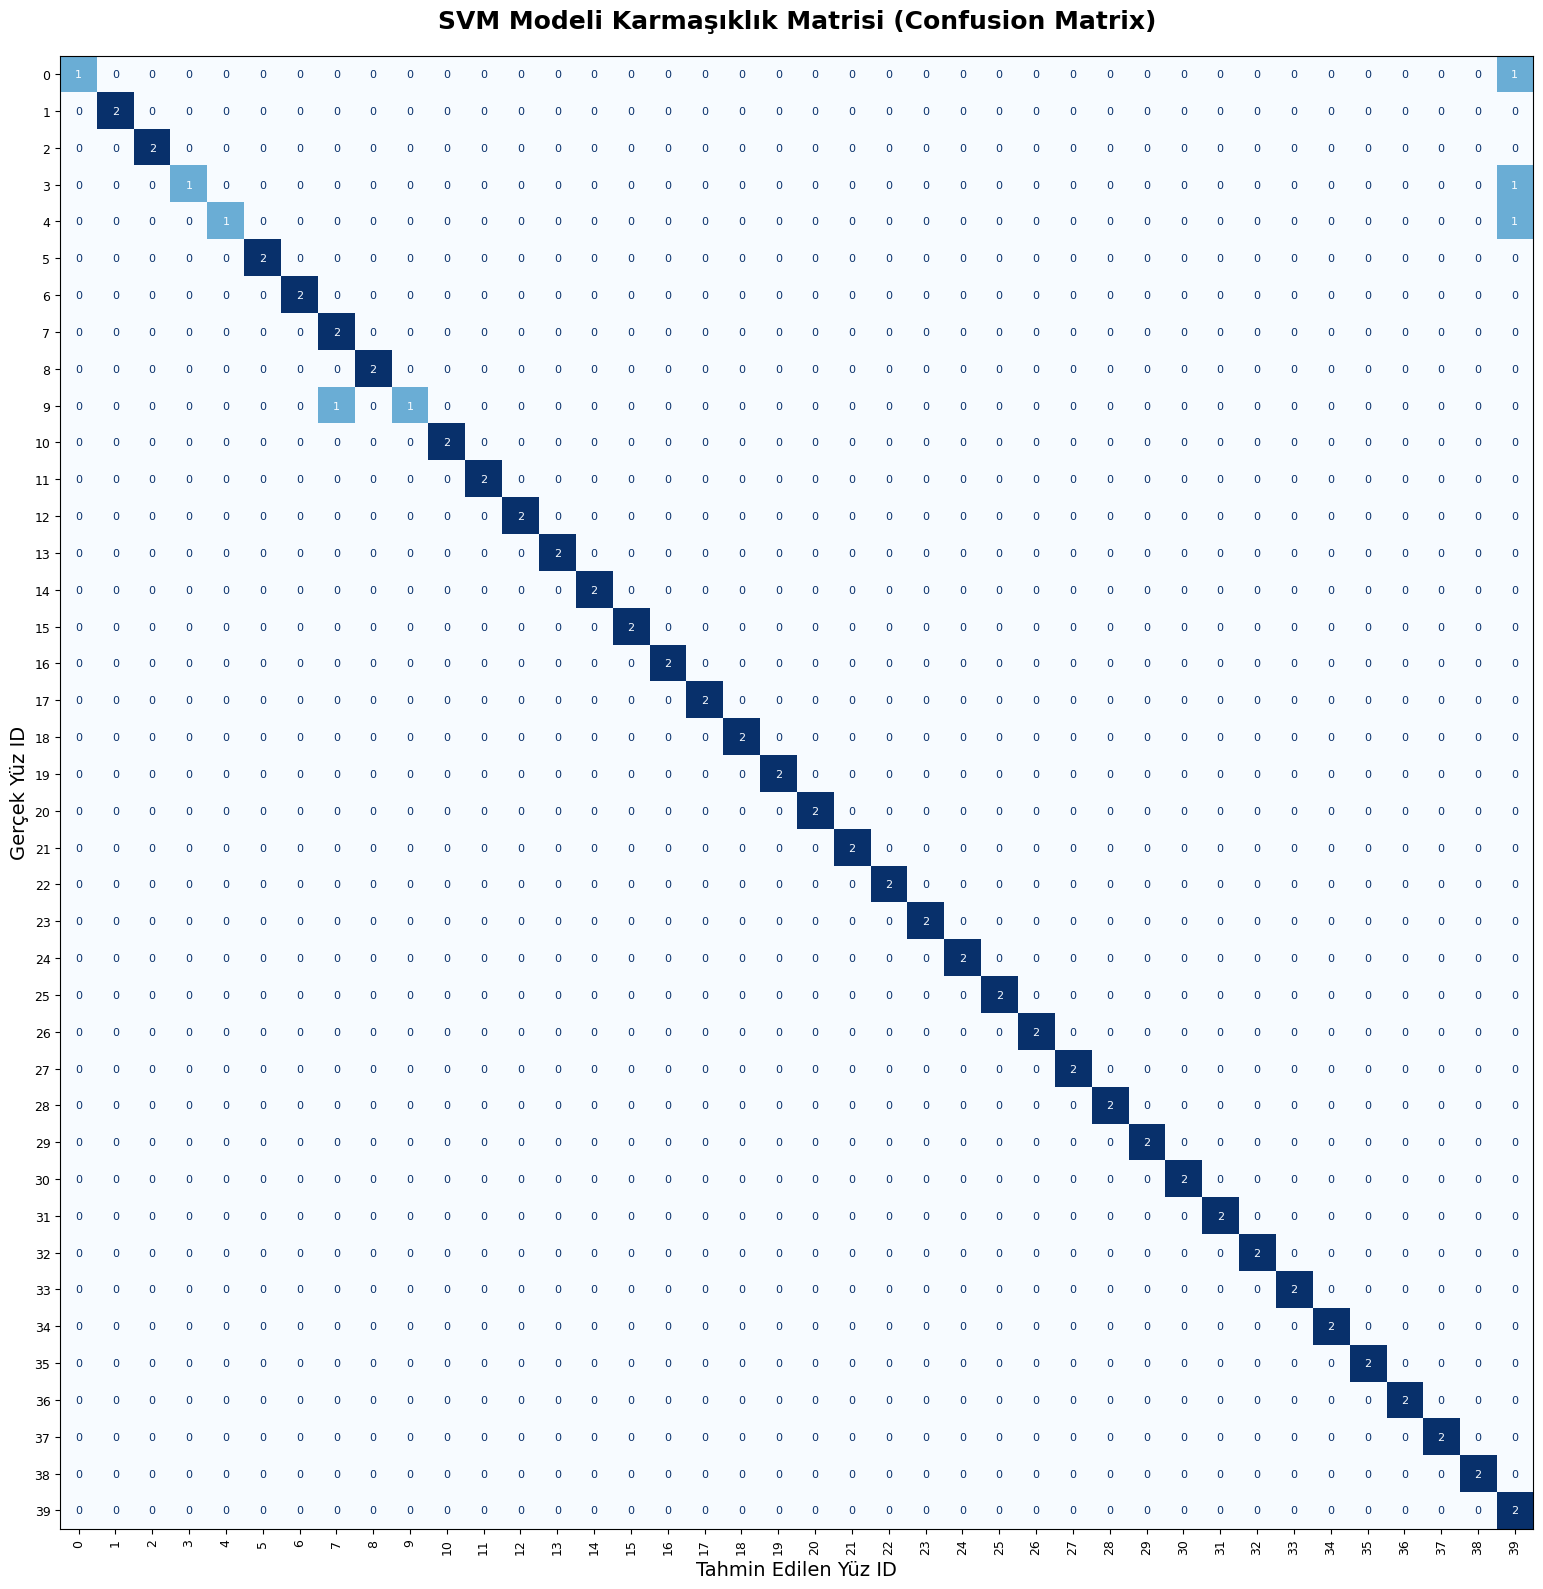

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 16))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    ax=ax,
    cmap='Blues',
    colorbar=False,
    text_kw={'fontsize': 8}
)

plt.title("SVM Modeli Karmaşıklık Matrisi (Confusion Matrix)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Tahmin Edilen Yüz ID", fontsize=14)
plt.ylabel("Gerçek Yüz ID", fontsize=14)

plt.xticks(fontsize=9, rotation=90)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
param_grid = {
    'pca__n_components': [80, 100, 120, 150],
    'clf__C': [1, 10, 100, 1000],
    'clf__gamma': ['scale', 'auto', 0.001, 0.005],
    'clf__kernel': ['rbf']
}

grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_sc, y_train)

best_svm_model = grid_search.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test_sc)

print(f"Best Params: {grid_search.best_params_}")
print(f"Tuned SVM Accuracy: {accuracy_score(y_test, y_pred_best_svm):.4f}")

Best Params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'pca__n_components': 150}
Tuned SVM Accuracy: 0.9750


Errors (Tuned SVM): 2


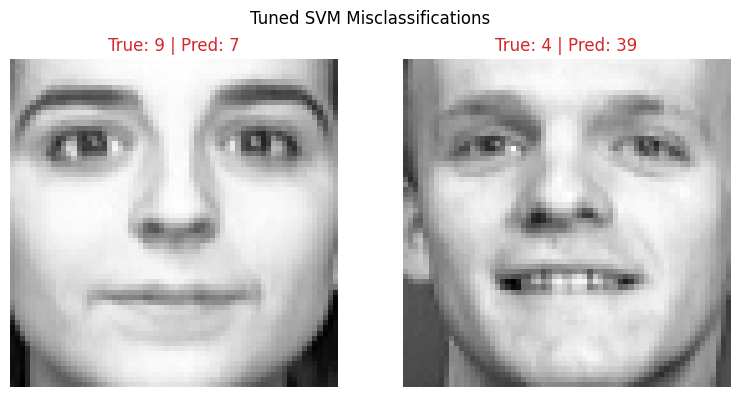

In [41]:
yeni_hatali_indeksler = np.where(y_test != y_pred_best_svm)[0]

print(f"Errors (Tuned SVM): {len(yeni_hatali_indeksler)}")

if len(yeni_hatali_indeksler) > 0:
    cols = min(5, len(yeni_hatali_indeksler))
    rows = (len(yeni_hatali_indeksler) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes_flat = np.atleast_1d(axes).flatten()

    for i, ax in enumerate(axes_flat):
        if i < len(yeni_hatali_indeksler):
            idx = yeni_hatali_indeksler[i]
            ax.imshow(X_test[idx].reshape(64, 64), cmap='gray', interpolation='nearest')
            ax.set_title(f"True: {y_test[idx]} | Pred: {y_pred_best_svm[idx]}", color='#d62728')
        ax.axis('off')

    plt.suptitle("Tuned SVM Misclassifications")
    plt.tight_layout()
    plt.show()